<a href="https://colab.research.google.com/github/starsyntaxx/Olist-delivery-prediction/blob/main/notebooks/exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. upload the files

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [3]:
import zipfile
import os

for file_name in uploaded.keys():
    if file_name.endswith(".zip"):
        with zipfile.ZipFile(file_name, 'r') as zip_ref:
            zip_ref.extractall("data")

Import tools.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
os.listdir("data")

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv',
 'olist_order_payments_dataset.csv']

Quick view of the whole daataset.

In [9]:

# Load datasets
orders = pd.read_csv("data/olist_orders_dataset.csv")
customers = pd.read_csv("data/olist_customers_dataset.csv")
geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")
order_reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
order_payments = pd.read_csv("data/olist_order_payments_dataset.csv")
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")

# Store datasets in dictionary
datasets = {
    "orders": orders,
    "customers": customers,
    "geolocation": geolocation,
    "order_reviews": order_reviews,
    "order_items": order_items,
    "order_payments": order_payments,
    "sellers": sellers,
    "products": products
}

# Find maximum number of columns among datasets
max_cols = max(len(df.columns) for df in datasets.values())

# Create schema dictionary
schema_data = {}

for name, df in datasets.items():
    cols = list(df.columns)

    # Pad shorter lists with None
    cols += [None] * (max_cols - len(cols))

    schema_data[name] = cols

# Create schema overview table
schema_table = pd.DataFrame.from_dict(
    schema_data,
    orient='index'
)

# Rename column headers
schema_table.columns = [f"Column_{i+1}" for i in range(max_cols)]

# Display table
schema_table

,Column_1,Column_2,Column_3,Column_4,Column_5,Column_6,Column_7,Column_8,Column_9
orders,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,None
customers,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,None,None,None,None
geolocation,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,None,None,None,None
order_reviews,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,None,None
order_items,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,None,None
order_payments,order_id,payment_sequential,payment_type,payment_installments,payment_value,None,None,None,None
sellers,seller_id,seller_zip_code_prefix,seller_city,seller_state,None,None,None,None,None
products,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


**Workflow 1: Analyze each dataset quality for signals before merging**


**Orders Dataset**

In [10]:
orders = pd.read_csv("data/olist_orders_dataset.csv")
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


QUESTIONS AND NOTE
Exploratory
1. Dataset: A general overview of the data
2. Data Quality: Check for misssing values, outliers, bad data
3. Dataset Relationship: Check relationship between a dataset to another in the whole data frame.
* Order ID - Customer ID - *one-one-relationship*
* Order ID - product ID - *one-one_relationship*
* Order ID - Seller ID
* Order ID - Customer Unique ID

Note: Each exploratory analysis produces complex questions, that will be answered along the way


In [13]:
orders.describe()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


 *Observation; Out of 99441 unque order, only 459 order etimated delivery date were spread out, a number of each had*

 *Hypothesis: A simple algorithm was included, does it stem from location only, was there a correlation*

In [15]:
orders.head()
orders.shape
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [11]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
#Hypothesis: Missing values exist

orders['not_delivered'] = orders['order_delivered_customer_date'].isnull()
orders.groupby('order_status')['not_delivered'].value_counts()

order_status  not_delivered
approved      True                 2
canceled      True               619
              False                6
created       True                 5
delivered     False            96470
              True                 8
invoiced      True               314
processing    True               301
shipped       True              1107
unavailable   True               609
Name: count, dtype: int64

In [14]:
orders['order_status'].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [16]:
orders[orders['order_status'] == 'shipped']['order_delivered_carrier_date'].isnull().sum()

np.int64(0)

*Missing values observed in delivery timestamp columns were analyzed and found to be primarily associated with the business process state of orders during data capture rather than database inconsistencies or system failures. Orders with statuses such as shipped, processing, or canceled naturally lacked certain downstream delivery timestamps because those events had not yet occurred at the time of recording.*

In [17]:
#Now unto data cleaning
df = orders[orders['order_status'] == 'delivered'].copy()
df['order_delivered_customer_date'].isnull().sum()

#observation: 8 customers with delivered tag are missing delivery dates


np.int64(8)

In [13]:

#question; How many times was the order day predicted wrongly: you can't get the exact time, but at least the day
df['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

df['delivery_delay_days'].head()

,delivery_delay_days
0,-8.0
1,-6.0
2,-18.0
3,-13.0
4,-10.0


On average, orders are delivered approximately 12 days earlier than the estimated delivery date, indicating that the estimation system is conservative. However, there is significant variability in delivery performance, with some extreme early and late deliveries, suggesting inconsistency in logistics or estimation accuracy.

In [14]:
df['delivery_delay_days'].describe()

,delivery_delay_days
count,31982.00000
mean,-11.85323
std,9.98537
min,-140.00000
25%,-17.00000
50%,-12.00000
75%,-7.00000
max,181.00000


In [17]:
df['delivery_delay_days'].value_counts()

,count
delivery_delay_days,
-14.0,2441
-13.0,1991
-15.0,1800
-7.0,1597
-8.0,1582
...,...
134.0,1
-75.0,1
153.0,1


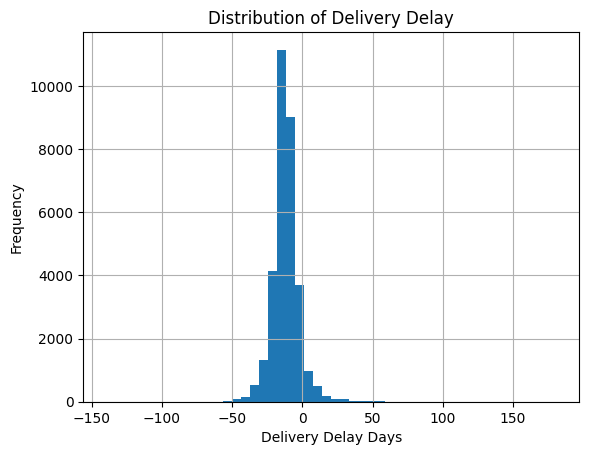

In [16]:

df['delivery_delay_days'].hist(bins=50)

plt.xlabel("Delivery Delay Days")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Delay")

plt.show()

In [35]:
#Was there any order delivery date that was predicted accurately to detect the accuracy of the delivery date?
df['delivery_matched_dates'] = (
    df['order_delivered_customer_date'].dt.date ==
    df['order_estimated_delivery_date'].dt.date
)

df['delivery_matched_dates'].describe()


,delivery_matched_dates
count,96478
unique,2
top,False
freq,95186


In [34]:
matched_orders = df[
    df['order_delivered_customer_date'].dt.date ==
    df['order_estimated_delivery_date'].dt.date
]

matched_orders.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
count,1292,1292,1292,1292.0
mean,2018-02-22 02:03:04.214396160,2018-03-13 07:23:39.443498496,2018-03-12 14:37:09.102167296,0.0
min,2016-10-10 15:01:27,2016-12-14 08:03:48,2016-12-14 00:00:00,0.0
25%,2017-11-25 15:09:24.500000,2017-12-19 15:58:24.500000,2017-12-19 00:00:00,0.0
50%,2018-03-07 09:55:52,2018-03-28 07:17:47,2018-03-28 00:00:00,0.0
75%,2018-07-16 12:12:06.500000,2018-08-01 06:08:30.750000128,2018-08-01 06:00:00,0.0
max,2018-08-28 22:51:54,2018-08-31 02:21:48,2018-08-31 00:00:00,0.0
std,NaN,NaN,NaN,0.0


*Out of 9912 orders and their delivery dates, 1291 orders were accurate as the estimated delivery time equaled the actual delivery date, 9586 were not accurate as the actual delivery dates deviated from the estimated delivery date*

MODEL USAGE
1. Filter out orders without a customer_actual_delivery_time as it is not needed for the model

**Data Frames for Modelling**
Important Filter == Delivered
1. Order Purchase timestamp
2. Order_approved_at
3. Order_estimated_delivery_date
4. Order_status
5. Order_delivered-customer_date

----------------------------------------------------------------Another Dataset--------------------------------------------------------

**Customers Dataset**

In [ ]:
customers = pd.read_csv("data/olist_customers_dataset.csv")
customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
# Check data quality and usability
# treat customer_zip_code_prefix as categorical data type so as To analyze distribution of customers across regions
customers["customer_zip_code_prefix"] = customers["customer_zip_code_prefix"].astype("category")
customers.describe()
#Unique_id is unique to every user, regaardless how many orders are made, it's the same.
# Check the ralationship of city distance with delivery date, if its the same for those with same city distance
#Look aat the yeer with 17 unique orders which correlate with 17 orders, check the relatinship of duration of estimated and actual delivery date with city

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441,99441,99441
unique,99441,96096,14994,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,22790,sao paulo,SP
freq,1,17,142,15540,41746


In [ ]:
customers.info()
# relationship question: Number of customers equals order, so the customer correlates with a one-one relationship with the order dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
# Did all of the customers here engage in orders?
# Observe the relationship between an order estimated time and (i)the review and (ii)number of times it was bought?


**Geolocation Dataset**; Not very important to answer question for now.

In [ ]:
geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")
geolocation.head(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [ ]:
geolocation.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [ ]:
geolocation.info()
# Exploration question: Geolocation dataset number does not equal order, what form of relationship does it have and with which dataset?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [ ]:
# How does the location of a buyer to a seller affect the delivery time of a buyer?
# Did the location of a buyer influence the algorithm used to estimate a delivery time; check using scatterplot. Is that why it gave the same delivery times to certain people, maybe perlocation the estimated time to receive aproduct is the same

**Order Review Dataset**

In [ ]:
order_reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
order_reviews.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Order Items Dataset**

In [ ]:
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [ ]:

#order_items['order_item_id'] = order_items['order_item_id'].astype('category')
#order_items['order_item_id'].describe()

order_items = order_items.astype('category')
order_items.describe()

#Question: The shipping limit date unique total values does not highly correlate with estimated delivery date. A high correlation should exist right?
# Check the relationship between the predicted output and shipping_limit_date	and	freight_value

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650,112650,112650,112650,112650.0,112650.0
unique,98666,21,32951,3095,93318,5968.0,6999.0
top,8272b63d03f5f79c56e9e4120aec44ef,1,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,59.9,15.1
freq,21,98666,527,2033,21,2481.0,3707.0


**Order Payments Dataset**

In [ ]:
order_payments = pd.read_csv("data/olist_order_payments_dataset.csv")
order_payments.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Sellers dataset**

In [ ]:
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
sellers.head(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


**Product Dataset**

In [ ]:
products = pd.read_csv('data/olist_products_dataset.csv')
products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


*Interacting with the product dataset.*

In [ ]:
products['product_category_name'].value_counts()

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
...,...
fashion_roupa_infanto_juvenil,5
casa_conforto_2,5
pc_gamer,3


In [ ]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


Analysis of the order Item dataset

In [ ]:
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
missing_products = products[products['product_category_name'].isnull()]
missing_products_ids = missing_products['product_id']
matched_orders = order_items[order_items['product_id'].isin(missing_products_ids)]

In [ ]:
matched_orders.head(20)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
123,0046e1d57f4c07c8c92ab26be8c3dfc0,1,ff6caf9340512b8bf6d2a2a6df032cfa,38e6dada03429a47197d5d584d793b41,2017-10-02 15:49:17,7.79,7.78
125,00482f2670787292280e0a8153d82467,1,a9c404971d1a5b1cbc2e4070e02731fd,702835e4b785b67a084280efca355756,2017-02-17 16:18:07,7.60,10.96
132,004f5d8f238e8908e6864b874eda3391,1,5a848e4ab52fd5445cdc07aab1c40e48,c826c40d7b19f62a09e2d7c5e7295ee2,2018-03-06 09:29:25,122.99,15.61
142,0057199db02d1a5ef41bacbf41f8f63b,1,41eee23c25f7a574dfaf8d5c151dbb12,e5a3438891c0bfdb9394643f95273d8e,2018-01-25 09:07:51,20.30,16.79
171,006cb7cafc99b29548d4f412c7f9f493,1,e10758160da97891c2fdcbc35f0f031d,323ce52b5b81df2cd804b017b7f09aa7,2018-02-22 13:35:28,56.00,14.14
370,00e6786fee8f476835c151a4d3fa9bf1,1,76d1a1a9d21ab677a61c3ae34b1b352f,c826c40d7b19f62a09e2d7c5e7295ee2,2018-03-15 01:31:04,159.77,16.00
378,00ed64bc080d87b4ab7f0c433bc5e98f,1,fbb1cfc2810efabf3235eccf4530f4ae,0c8380b62e38e8a1e6adbeba7eb9688c,2017-06-06 18:22:47,44.90,16.11
434,010a35dc7fc3808a03d243d2fd8c6e35,1,5a848e4ab52fd5445cdc07aab1c40e48,c826c40d7b19f62a09e2d7c5e7295ee2,2017-12-21 19:10:15,122.99,9.06
454,011080783e02d05b26c8c158b3653a42,1,9f69acd4da62618a3f6365b732d00ccd,897060da8b9a21f655304d50fd935913,2018-06-22 15:38:55,33.90,13.82
456,011108c8a3d6eee6807f48a2e639439f,1,ea11e700a343582ad56e4c70e966cb36,01cf7e3d21494c41fb86034f2e714fa1,2017-05-02 17:42:48,593.36,98.13


In [ ]:
matched_orders['product_id'].nunique()

610

In [ ]:
missing_products_ids.nunique()

610

Matched